# Filters

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davidrajm/DSA-DL-FDP/blob/main/Day%2005%20-%20CNN%20-%20%20Dr%20Saraswathi/filters.ipynb
)

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Load Image
# -----------------------------
# Upload image in Colab or give path

from google.colab import files
uploaded = files.upload()


Saving star.png to star.png


In [5]:
image = cv2.imread('star.png')

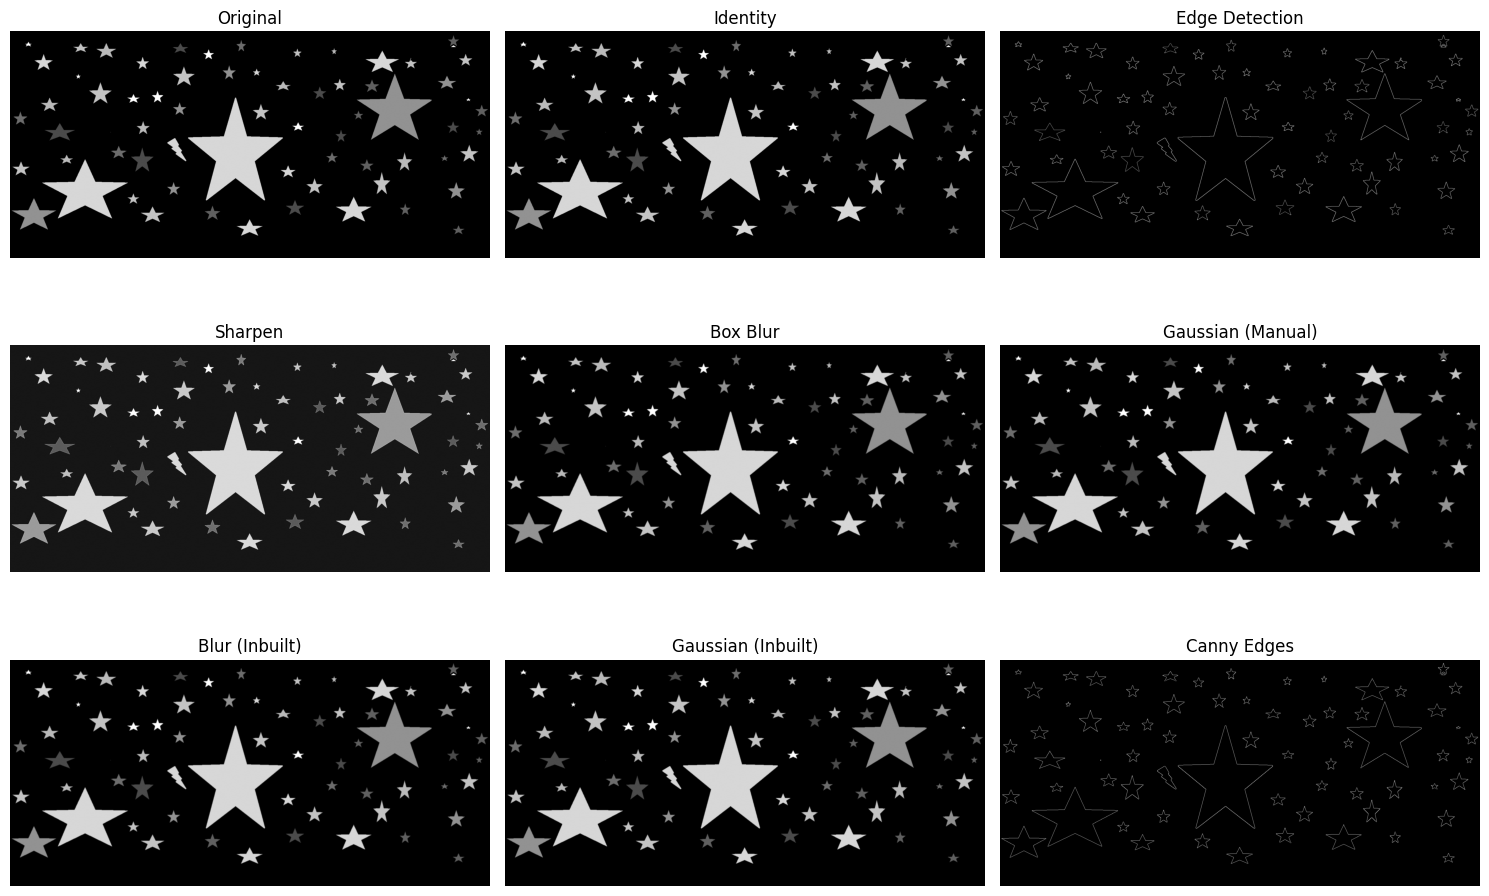

In [6]:
#image = cv2.imread('/content/image.jpg')  # change path
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale (simpler for teaching)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# -----------------------------
# Step 2: Define Kernels
# -----------------------------

# Identity
identity = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
])

# Edge Detection
edge = np.array([
    [1, 1, 1],
    [1, -8, 1],
    [1, 1, 1]
])

# Sharpen
sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# Box Blur
box_blur = (1/9) * np.ones((3,3))

# Gaussian Blur
gaussian = (1/16) * np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
])

# -----------------------------
# Step 3: Apply Kernels (Manual via OpenCV filter2D)
# -----------------------------
identity_img = cv2.filter2D(gray, -1, identity)
edge_img = cv2.filter2D(gray, -1, edge)
sharpen_img = cv2.filter2D(gray, -1, sharpen)
box_img = cv2.filter2D(gray, -1, box_blur)
gaussian_img = cv2.filter2D(gray, -1, gaussian)

# -----------------------------
# Step 4: Inbuilt Functions
# -----------------------------
blur_builtin = cv2.blur(gray, (3,3))
gaussian_builtin = cv2.GaussianBlur(gray, (3,3), 0)
canny_edges = cv2.Canny(gray, 100, 200)

# -----------------------------
# Step 5: Display Results
# -----------------------------
titles = [
    "Original", "Identity", "Edge Detection", "Sharpen",
    "Box Blur", "Gaussian (Manual)",
    "Blur (Inbuilt)", "Gaussian (Inbuilt)", "Canny Edges"
]

images = [
    gray, identity_img, edge_img, sharpen_img,
    box_img, gaussian_img,
    blur_builtin, gaussian_builtin, canny_edges
]

plt.figure(figsize=(15,10))

for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()